In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Data preparation

In [3]:
df = pd.read_csv("data\\Personality_Syncora_Synthetic.csv")

In [4]:
round(df.describe())

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
count,4998.0,4998.0,4998.0,4998.0,4998.0,4998.0,4998.0,4998.0
mean,4.0,0.0,4.0,3.0,0.0,6.0,4.0,0.0
std,3.0,0.0,3.0,2.0,0.0,4.0,3.0,0.0
min,-1.0,0.0,-1.0,-1.0,0.0,-1.0,-1.0,0.0
25%,2.0,0.0,2.0,1.0,0.0,3.0,1.0,0.0
50%,4.0,0.0,4.0,3.0,0.0,5.0,3.0,0.0
75%,7.0,1.0,6.0,5.0,1.0,10.0,6.0,1.0
max,12.0,1.0,11.0,8.0,1.0,16.0,11.0,1.0


- 'Time_spent_Alone': from -1 to 12,
-  'Stage_fear': boolean, 
- 'Social_event_attendance': -1 to 11,
- 'Going_outside': from -1 to 8, 
- 'Drained_after_socializing': boolean, 
- 'Friends_circle_size': -1 to 16,
- 'Post_frequency': -1 to 11, 
- 'Personality': boolean

In [5]:
df.columns = df.columns.str.lower()

In [6]:
df.columns

Index(['time_spent_alone', 'stage_fear', 'social_event_attendance',
       'going_outside', 'drained_after_socializing', 'friends_circle_size',
       'post_frequency', 'personality'],
      dtype='object')

## Exploratory Data Analysis (EDA)

In [7]:
print(f"Extroverts: {(df['personality'] == 0).sum()}\nIntroverts: {(df['personality'] == 1).sum()}")

Extroverts: 2597
Introverts: 2401


In [8]:
df[(df==-1)].sum()

time_spent_alone            -61.0
stage_fear                    0.0
social_event_attendance     -26.0
going_outside                -7.0
drained_after_socializing     0.0
friends_circle_size         -20.0
post_frequency              -39.0
personality                   0.0
dtype: float64

In [9]:
print(f'Missing values: {df.isnull().sum()}')

Missing values: time_spent_alone             0
stage_fear                   0
social_event_attendance      0
going_outside                0
drained_after_socializing    0
friends_circle_size          0
post_frequency               0
personality                  0
dtype: int64


In [10]:
print(f'\nUnique values count per column: \n{df.nunique()}')
print(f'\nNumber of negative value: \n{(df<0).sum()}') # errors? 


Unique values count per column: 
time_spent_alone             14
stage_fear                    2
social_event_attendance      13
going_outside                10
drained_after_socializing     2
friends_circle_size          18
post_frequency               13
personality                   2
dtype: int64

Number of negative value: 
time_spent_alone             61
stage_fear                    0
social_event_attendance      26
going_outside                 7
drained_after_socializing     0
friends_circle_size          20
post_frequency               39
personality                   0
dtype: int64


Distribution of all features:


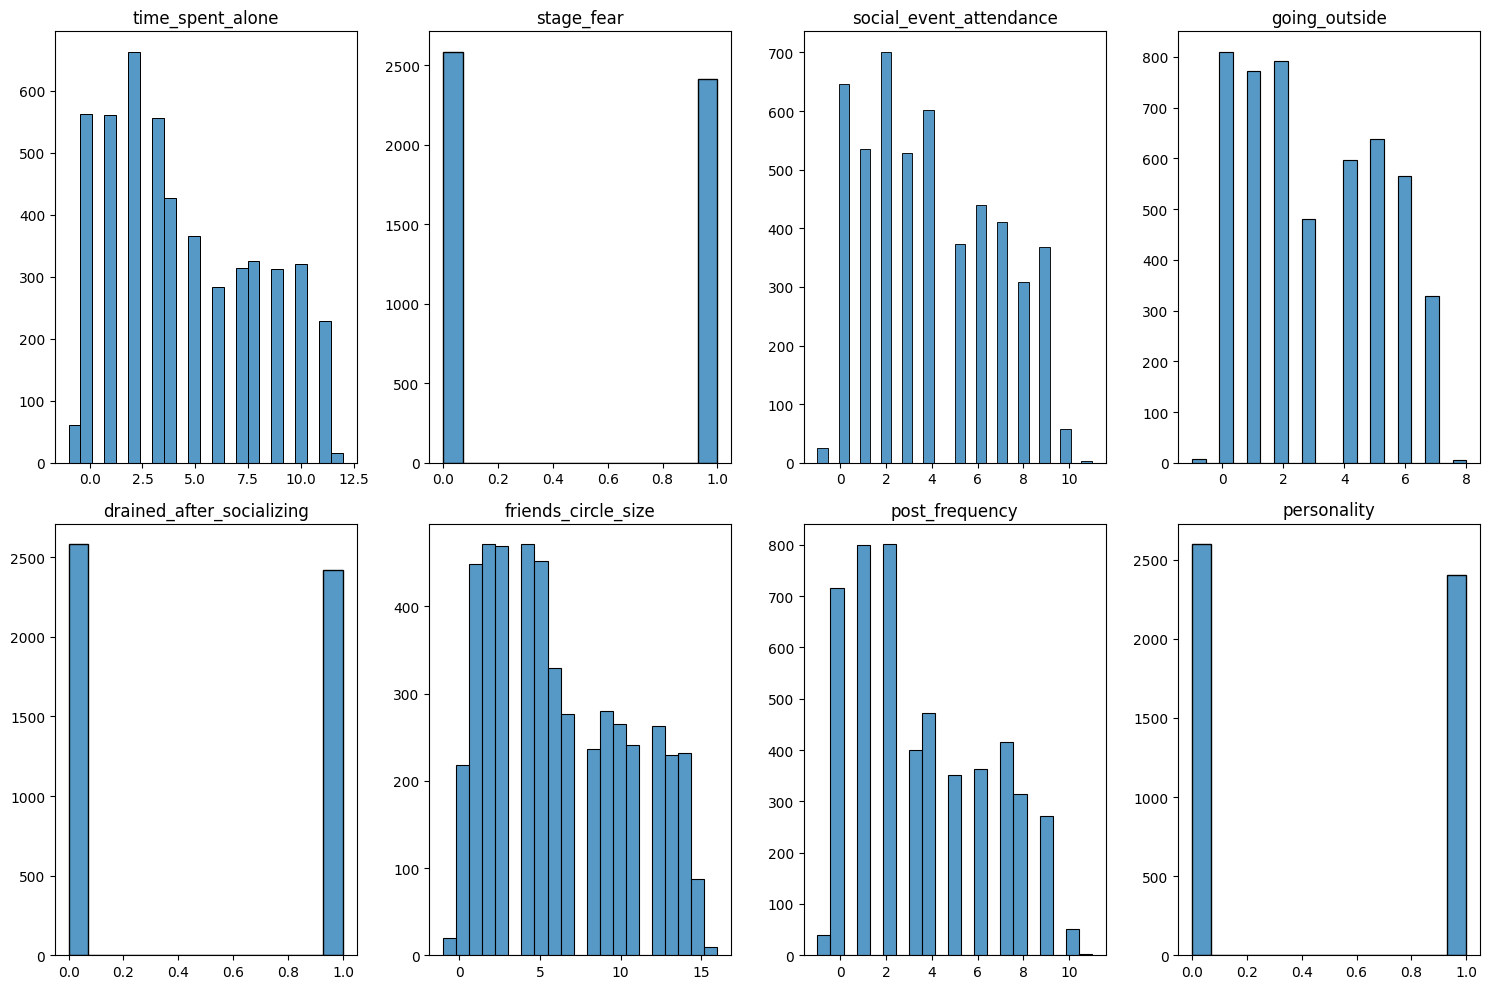

In [11]:
print("Distribution of all features:")
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(15, 10))
axes = axes.flatten()
features_to_plot =  df.columns.values
for i, col in enumerate(features_to_plot):
    sns.histplot(df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

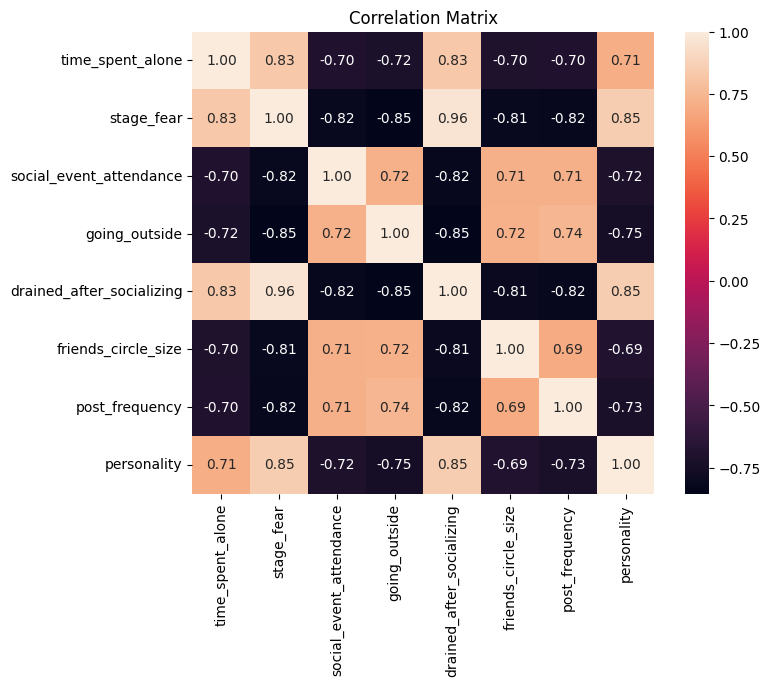

In [12]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", square=True)
plt.title("Correlation Matrix")
plt.show()

### Feature importance

In [13]:
global_mean = df.personality.mean()
print("Percentace of intorverted personality: ", round(global_mean, 2))

Percentace of intorverted personality:  0.48


In [14]:
df.columns

Index(['time_spent_alone', 'stage_fear', 'social_event_attendance',
       'going_outside', 'drained_after_socializing', 'friends_circle_size',
       'post_frequency', 'personality'],
      dtype='object')

In [15]:
df_introvert = df[df['personality']==1]
df_extrovert = df[df['personality']==0]

In [16]:
numerical_features = ['time_spent_alone', 'social_event_attendance','going_outside','friends_circle_size','post_frequency']

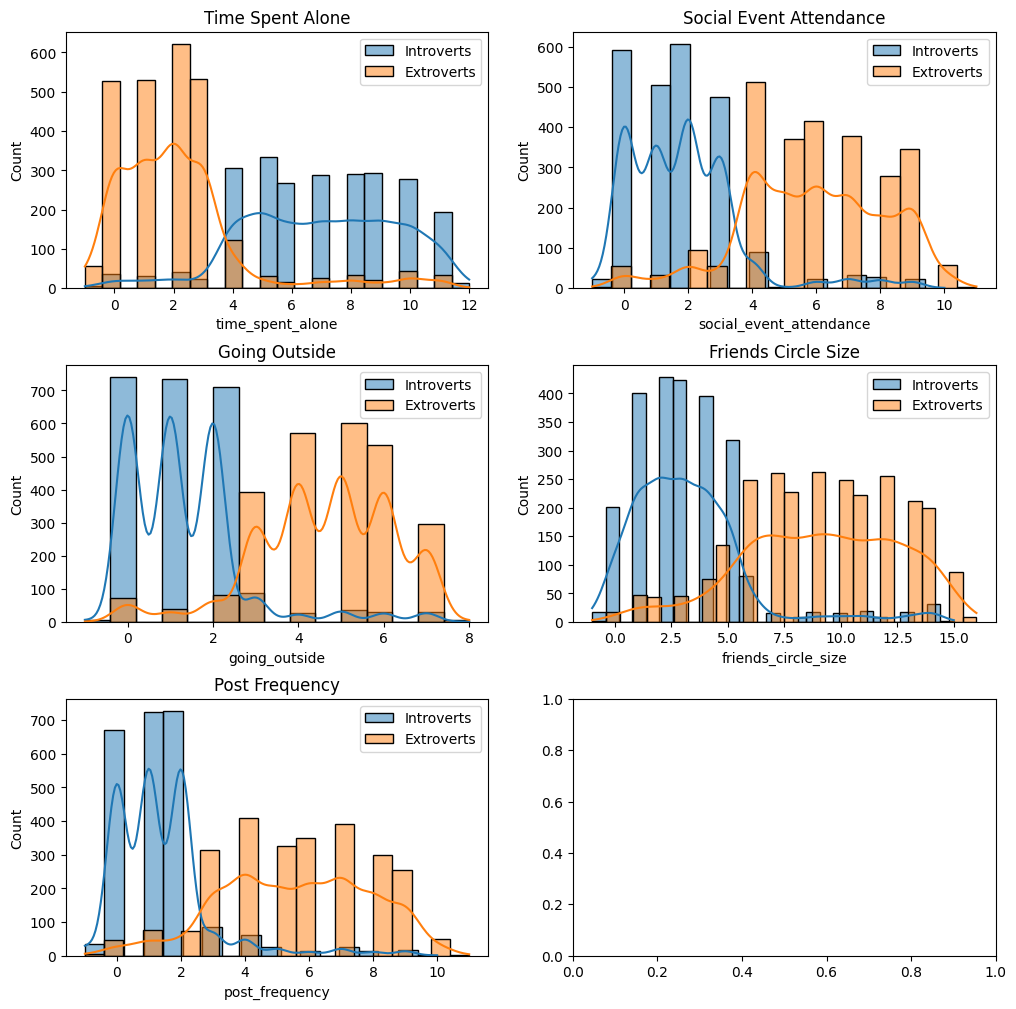

In [17]:
fig, axes = plt.subplots(3, 2, figsize=(12, 4 * 3))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    ax = axes[i]
    sns.histplot(df_introvert[feature], binwidth=0.6, kde=True, label='Introverts', ax=ax)
    sns.histplot(df_extrovert[feature], binwidth=0.6, kde=True, label='Extroverts', ax=ax)
    
    ax.set_title(feature.replace('_', ' ').title())
    ax.set_xlabel(feature)
    ax.legend()

fig.subplots_adjust(hspace=0.3)  # increase vertical spacing
plt.show()

In [18]:
df[df['stage_fear']==1].personality.mean()

np.float64(0.920049710024855)

In [19]:
df[df['drained_after_socializing']==1].personality.mean()

np.float64(0.9201489449731072)

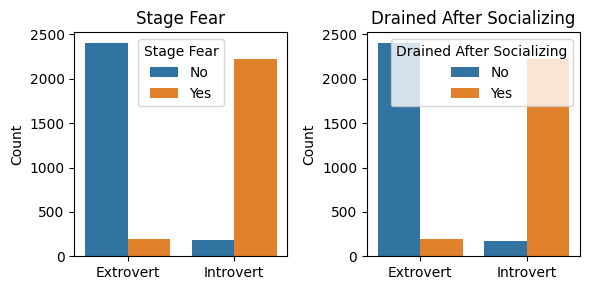

In [20]:
bool_features = ['stage_fear', 'drained_after_socializing']
fig, axes = plt.subplots(1, len(bool_features), figsize=(6, 3))
df_personality = df.copy()
df_personality['personality_label'] = df['personality'].map({1: 'Introvert', 0: 'Extrovert'})
for i, feature in enumerate(bool_features):
    ax = axes[i]
    sns.countplot(
        data=df_personality,
        x='personality_label',
        hue=feature,
        ax=ax
    )
    ax.set_title(feature.replace('_', ' ').title())
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.legend(title=feature.replace('_', ' ').title(), labels=['No', 'Yes'])
    
plt.tight_layout()
plt.show()


In [21]:
from sklearn.metrics import mutual_info_score

def mutual_info_personality(series):
    return mutual_info_score(series, df.personality)

mi = df.apply(mutual_info_personality)
mi.sort_values(ascending=False)

personality                  0.692378
drained_after_socializing    0.428670
stage_fear                   0.427116
going_outside                0.420645
social_event_attendance      0.405297
time_spent_alone             0.403259
post_frequency               0.402769
friends_circle_size          0.359303
dtype: float64

### Data imputation
Some of the features have missing values recorde with -1. We will handle this by median imputation.

In [22]:
df = df.replace(-1,np.nan)
df['time_spent_alone'].fillna(df['time_spent_alone'].median(), inplace=True)
df['social_event_attendance'].fillna(df['social_event_attendance'].median(), inplace=True)
df['going_outside'].fillna(df['going_outside'].median(), inplace=True)
df['friends_circle_size'].fillna(df['friends_circle_size'].median(), inplace=True)
df['post_frequency'].fillna(df['post_frequency'].median(), inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_8776\2018989630.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['time_spent_alone'].fillna(df['time_spent_alone'].median(), inplace=True)
C:\Users\User\AppData\Local\Temp\ipykernel_8776\2018989630.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh

## Model training and selection
- Logistic regrassion
- Desicion Tree
- Random Forest
- XGBoost

In [23]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, export_text
import xgboost as xgb

In [24]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)
len(df_train), len(df_val), len(df_test)

(2998, 1000, 1000)

In [25]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [26]:
y_train = df_train.personality.values
y_val = df_val.personality.values
y_test = df_test.personality.values

del df_train['personality']
del df_val['personality']
del df_test['personality']

In [27]:
X_train = df_train.values
X_val = df_val.values
X_test = df_test.values

In [28]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X_train, y_train)
pd.DataFrame({"features": df_train.columns.values, "MI":mi})

,features,MI
0,time_spent_alone,0.389720
1,stage_fear,0.422186
2,social_event_attendance,0.394344
3,going_outside,0.425328
4,drained_after_socializing,0.427159
5,friends_circle_size,0.371567
6,post_frequency,0.405170


In [29]:
from sklearn.metrics import roc_curve, roc_auc_score

def plot_roc_auc(y_true, y_scores, label='Model'):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    auc_score = roc_auc_score(y_true, y_scores)

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, color='blue', label=f'{label} (AUC = {auc_score:.3f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.show()

In [30]:
def train(X_train, y_train, model_class, hyperparams=None):
    if hyperparams is None:
        hyperparams = {}
    model = model_class(**hyperparams)
    model.fit(X_train, y_train)
    return model
    
def predict(X_val, model):
    y_pred = model.predict_proba(X_val)[:,1]
    return y_pred

def train_validate_model(X_train, y_train, X_val, y_val, model_class, hyperparams=None, plot_curve=False):
    model = train(X_train, y_train, model_class, hyperparams)
    y_pred = predict(X_val, model)
    if plot_curve:
        plot_roc_auc(y_val, y_pred, model_class.__name__)
    return model

In [31]:
def cross_fold_validation(df_full_train, model_class, hyperparams=None, plot_curve=False):
    kfold = KFold(n_splits = 5, shuffle=True, random_state=1)
    if plot_curve:
        plt.figure(figsize=(8,6))
        
    scores = []
    for train_idx, val_idx in kfold.split(df_full_train):
        df_train_kf = df_full_train.iloc[train_idx]
        df_val_kf = df_full_train.iloc[val_idx]
        y_train_kf = df_full_train['personality'].iloc[train_idx].values
        y_val_kf = df_full_train['personality'].iloc[val_idx].values
        
        X_train_kf = df_train_kf.drop(columns=['personality']).values
        X_val_kf = df_val_kf.drop(columns=['personality']).values
        
        model_kf = train(X_train_kf, y_train_kf, model_class, hyperparams)
        y_val_kf_pred = predict(X_val_kf, model_kf)
        score = roc_auc_score(y_val_kf, y_val_kf_pred)
        # print(f"AUROC score: {score}")
        scores.append(score)
        
        if plot_curve:
            fpr, tpr, _ = roc_curve(y_val_kf, y_val_kf_pred)
            plt.plot(fpr, tpr, lw=1.5, label=f'Fold {i} (AUC = {score:.3f})')
            
    if plot_curve: 
        plt.plot([0, 1], [0, 1], 'k--', lw=1)
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curves for {model_class.__name__} (K-Fold CV)')
        plt.legend(loc='lower right')
        plt.grid(alpha=0.3)
        plt.show()
        
        
    return scores


In [32]:
def hyperparameter_study(param_name, param_values, model_class, fixed_params={}, plot_study= False):
    dict_scores = {}
    for v in param_values:
        hyperparams = {**fixed_params, param_name: v}
        scores = cross_fold_validation(df_full_train, model_class = model_class, hyperparams = hyperparams)
        dict_scores[v] = scores
        
    if plot_study:
        param_values = list(dict_scores.keys())
        mean_auc = [np.mean(dict_scores[v]) for v in param_values]
        std_auc = [np.std(dict_scores[v]) for v in param_values]

        plt.figure(figsize=(8,5))
        plt.errorbar(param_values, mean_auc, yerr=std_auc, fmt='-o', capsize=5, color='steelblue')
        plt.xlabel(param_name)
        plt.ylabel('Mean AUROC (± std)')
        plt.title(f'Cross-validated AUROC vs {param_name}')
        plt.grid(True, alpha=0.3)
        plt.show()
    
    return dict_scores


def hyperparameter_grid_study(X_train, y_train, X_val, y_val, model_class,
                              param1_name, param1_values,
                              param2_name, param2_values,
                              fixed_params=None, plot=True):
    if fixed_params is None:
        fixed_params = {}
        
    results = []

    for v1 in param1_values:
        for v2 in param2_values:
            params = {**fixed_params, param1_name: v1, param2_name: v2}

            model = model_class(**params)
            model.fit(X_train, y_train)

            y_pred = model.predict_proba(X_val)[:, 1]
            
            auc = roc_auc_score(y_val, y_pred)
            results.append((v1, v2, auc))
    
    df_scores = pd.DataFrame(results, columns=[param1_name, param2_name, 'auc'])
    df_pivot = df_scores.pivot(index=param2_name, columns=param1_name, values='auc')
    
    if plot:
        plt.figure(figsize=(8, 6))
        sns.heatmap(df_pivot, annot=True, fmt=".3f", cmap="viridis")
        plt.title(f"AUC Heatmap: {param1_name} vs {param2_name}")
        plt.xlabel(param1_name)
        plt.ylabel(param2_name)
        plt.tight_layout()
        plt.show()
    
        

## Logistic Regression

In [33]:
from sklearn.linear_model import LogisticRegression
lg = LogisticRegression()
lg.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [34]:
dict(zip(df_train.columns.values,lg.coef_[0].round(3)))

{'time_spent_alone': np.float64(-0.036),
 'stage_fear': np.float64(2.358),
 'social_event_attendance': np.float64(-0.081),
 'going_outside': np.float64(-0.011),
 'drained_after_socializing': np.float64(2.694),
 'friends_circle_size': np.float64(0.076),
 'post_frequency': np.float64(-0.135)}

In [35]:
y_pred = lg.predict_proba(X_val)

In [36]:
y_pred_introvert = (y_pred[:,1] >= 0.5)

In [37]:
(y_pred_introvert == y_val).mean()

np.float64(0.93)

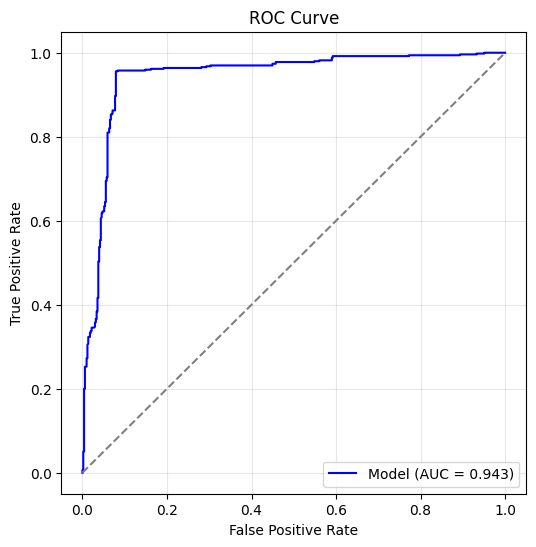

In [38]:
plot_roc_auc(y_val, y_pred[:,1])

#### Cross Validation

In [39]:
scores_logistic_regression = cross_fold_validation(df_full_train, LogisticRegression)   
print("AUC scores:", [round(s, 3) for s in scores_logistic_regression])
print("Mean AUC:", round(np.mean(scores_logistic_regression), 6))
print("Std AUC:", round(np.std(scores_logistic_regression), 3))

AUC scores: [0.946, 0.928, 0.948, 0.943, 0.949]
Mean AUC: 0.94295
Std AUC: 0.008


In [40]:
C = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
scores_c = {}
for c in C:
    scores = cross_fold_validation(df_full_train, model_class = LogisticRegression, hyperparams = {'C': c})
    scores_c[c] = scores

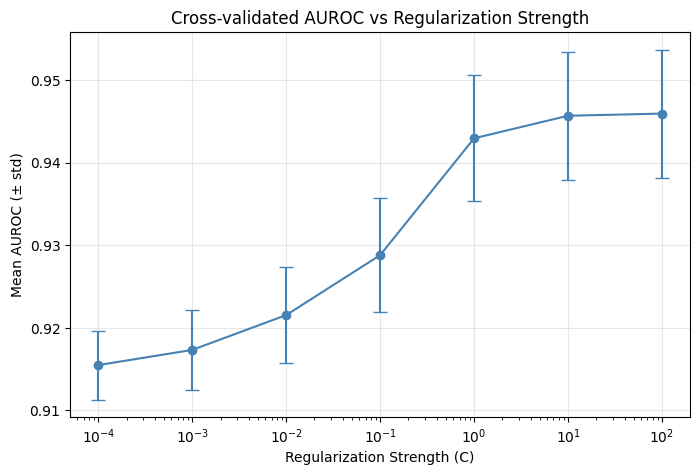

In [41]:
C_values = list(scores_c.keys())
mean_auc = [np.mean(scores_c[c]) for c in C_values]
std_auc = [np.std(scores_c[c]) for c in C_values]

plt.figure(figsize=(8,5))
plt.errorbar(C_values, mean_auc, yerr=std_auc, fmt='-o', capsize=5, color='steelblue')
plt.xscale('log')  # logistic regression C usually on log scale
plt.xlabel('Regularization Strength (C)')
plt.ylabel('Mean AUROC (± std)')
plt.title('Cross-validated AUROC vs Regularization Strength')
plt.grid(True, alpha=0.3)
plt.show()

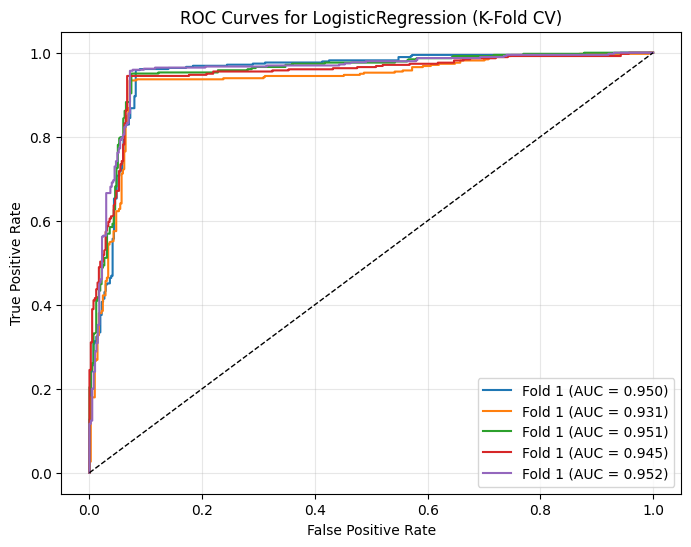

np.float64(0.9456816750576295)

In [43]:
lr_params = {'C': 10}
lr_scores = cross_fold_validation(df_full_train, LogisticRegression, lr_params, plot_curve=True)
np.mean(lr_scores)

## Decision trees

In [44]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict_proba(X_val)[:,1]
roc_auc_score(y_val, y_pred_dt)

0.9299789978997901

In [45]:
train_validate_model(X_train, y_train, X_val, y_val, DecisionTreeClassifier)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


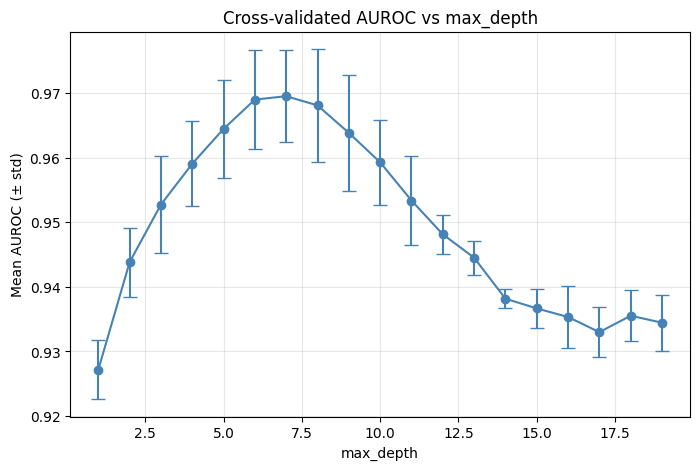

In [46]:
max_depth_list = np.arange(1,20,1)
dict_scores = hyperparameter_study('max_depth', max_depth_list,DecisionTreeClassifier, plot_study=True)

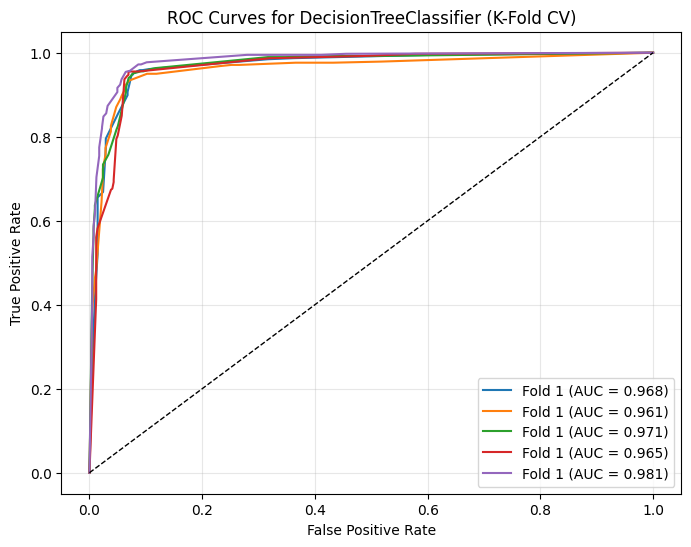

In [47]:
s = cross_fold_validation(df_full_train, DecisionTreeClassifier, {'max_depth': 7}, plot_curve=True)

In [48]:
dt_params = {
    'max_depth': 7 
}

In [49]:
#Investigate the number of samples in leaves 
dt = train_validate_model(X_train, y_train, X_val, y_val, DecisionTreeClassifier, {'max_depth': 7}, plot_curve=False)

n_node_samples = dt.tree_.n_node_samples
is_leaf = dt.tree_.children_left == -1
n_node_samples[is_leaf]

array([227, 177, 244, 401, 240,  35,  80,  10,   7,  27,  13,   3,  15,
        37,  10,   4,   4,  30,  10,   8,   3,   2,  11,   2,   2,  11,
         7,   1, 207, 120, 140,   4,   2,   2,   6,   4,   6, 154,  99,
        36,  88,  60,  54,  19,  28,  63,   8,  19,  36,  20,  29,   6,
        12,  85,  36,   1,  12,   4,   4,  13])

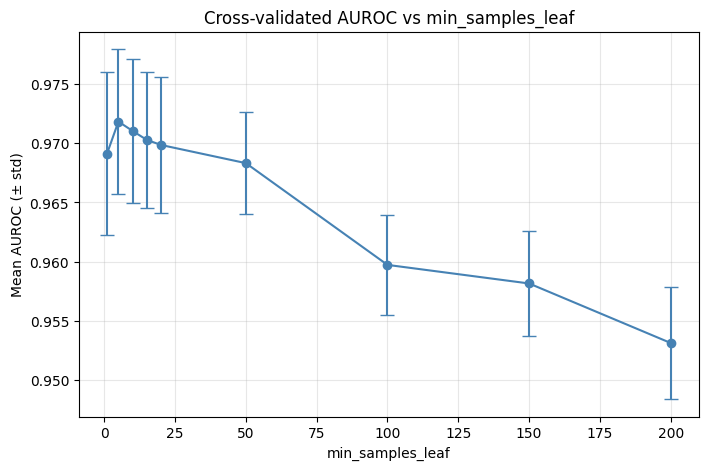

In [50]:
min_samples_leaf_list = [1, 5, 10, 15, 20, 50, 100, 150, 200]
scores = hyperparameter_study('min_samples_leaf', min_samples_leaf_list, DecisionTreeClassifier, fixed_params=dt_params, plot_study=True)

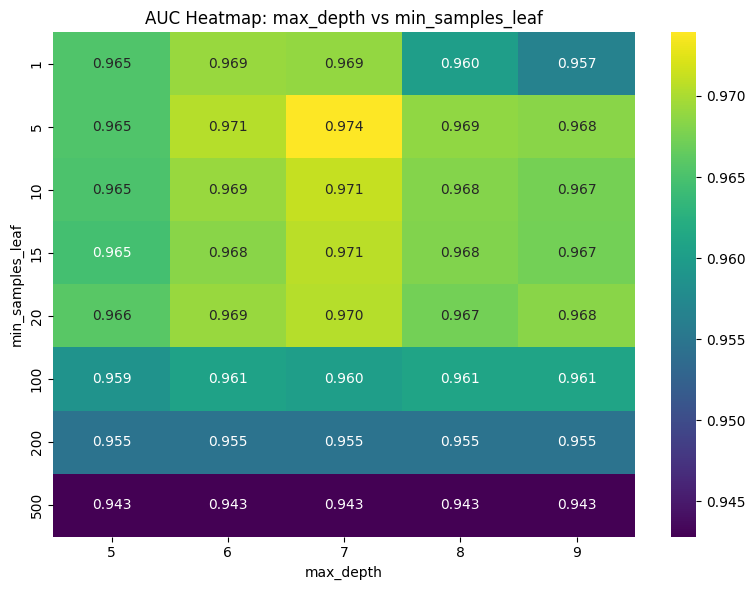

In [51]:
hyperparameter_grid_study(X_train, y_train, X_val, y_val, DecisionTreeClassifier, 
                          'max_depth', [5, 6, 7, 8, 9],
                          'min_samples_leaf', [1, 5, 10, 15, 20, 500, 100, 200])

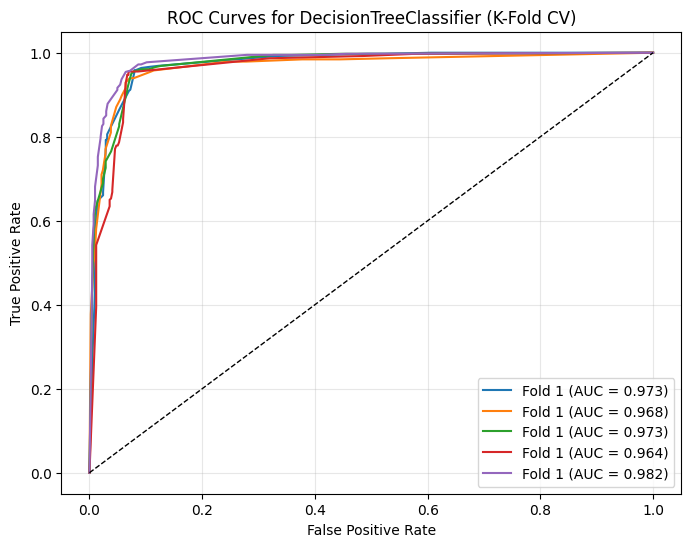

np.float64(0.9717481503524841)

In [53]:
#Final model
dt_params = {
    'max_depth': 7,
    'min_samples_leaf':5
}
scores_dt = cross_fold_validation(df_full_train, DecisionTreeClassifier, dt_params, plot_curve=True)
np.mean(scores_dt)


## Random Forest

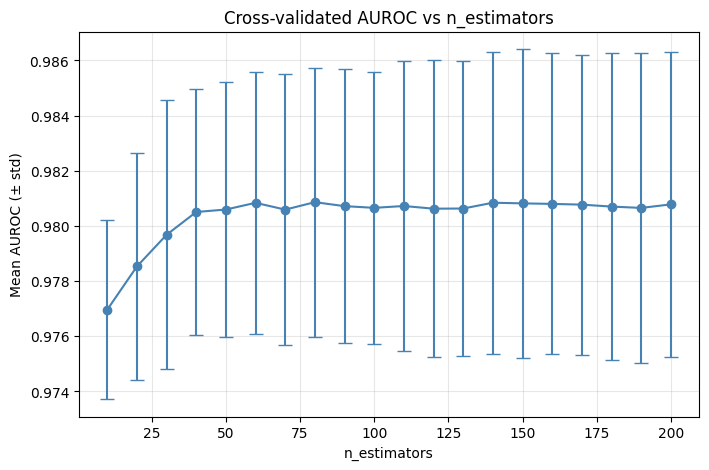

In [55]:
n_estimators_list = np.arange(10,201,10)
s = hyperparameter_study('n_estimators', n_estimators_list, RandomForestClassifier, fixed_params={'random_state': 1}, plot_study=True)

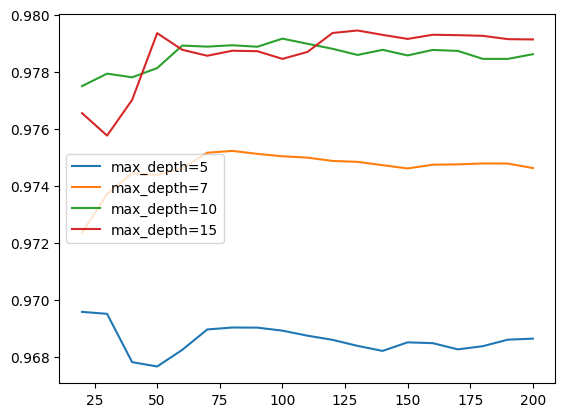

In [56]:
scores = []
depths = [5, 7, 10, 15]
for d in depths:
    for n in range(20, 201, 10):
        rf = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=1)
        rf.fit(X_train, y_train)
        y_pred = rf.predict_proba(X_val)[:,1]
        auc = roc_auc_score(y_val, y_pred)
        scores.append((d,n,auc))
        


columns = ['max_depth', 'n_estimators', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)

for d in depths:
    df_subset = df_scores[df_scores.max_depth == d]
    
    plt.plot(df_subset.n_estimators, df_subset.auc,
             label='max_depth=%d' % d)

plt.legend()



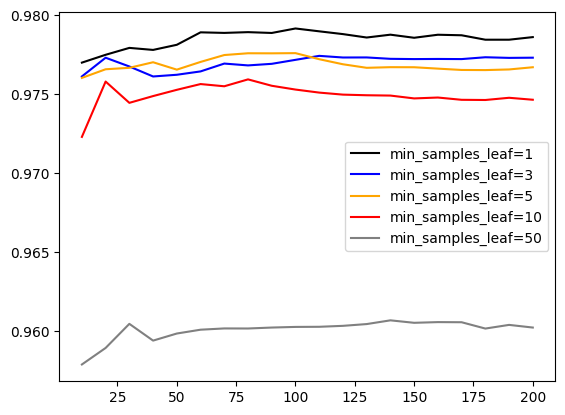

In [57]:
scores = []
min_sample_leaf_list = [1, 3, 5, 10, 50]
for s in min_sample_leaf_list:
    for n in range(10, 201, 10):
        rf = RandomForestClassifier(n_estimators=n,
                                    max_depth=10,
                                    min_samples_leaf=s,
                                    random_state=1)
        rf.fit(X_train, y_train)

        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)

        scores.append((s, n, auc))

columns = ['min_samples_leaf', 'n_estimators', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)

colors = ['black', 'blue', 'orange', 'red', 'grey']
values = min_sample_leaf_list

for s, col in zip(values, colors):
    df_subset = df_scores[df_scores.min_samples_leaf == s]
    
    plt.plot(df_subset.n_estimators, df_subset.auc,
             color=col,
             label='min_samples_leaf=%d' % s)

plt.legend()

In [58]:
rf_params = {
    'n_estimators': 100,
    'max_depth': 10,
    'min_samples_leaf': 1
}

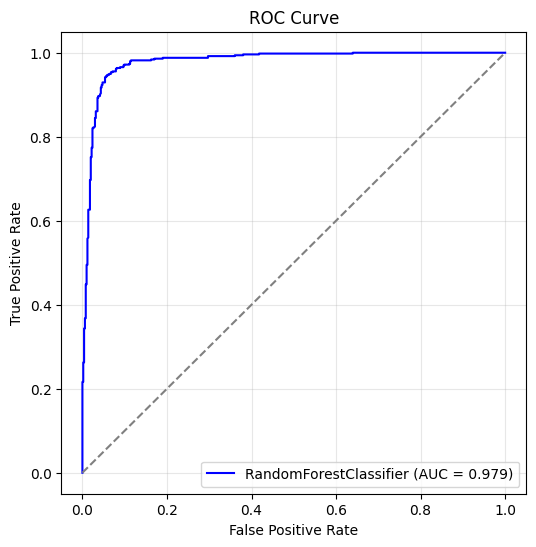

In [59]:
model = train_validate_model(X_train, y_train, X_val, y_val, RandomForestClassifier, rf_params, plot_curve=True)

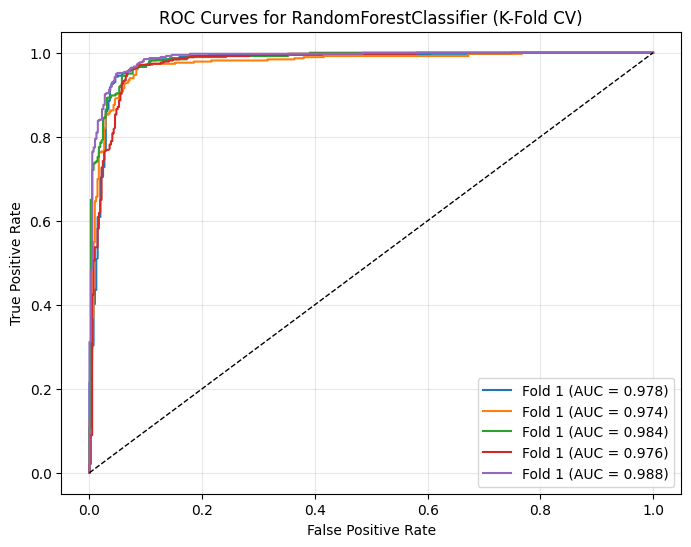

In [60]:
scores_rf = cross_fold_validation(df_full_train, RandomForestClassifier, rf_params, plot_curve=True)

In [61]:
np.mean(scores_rf)

np.float64(0.9801112394546504)

## XGBoost

In [62]:
features = list(df_train.columns)
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)

In [63]:
xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}


model = xgb.train(xgb_params, dtrain, num_boost_round=10)
y_pred = model.predict(dval)
roc_auc_score(y_val, y_pred)

0.9738093809380939

In [64]:
eta = [0.01, 0.05, 0.1, 0.2]
max_depth =  [3, 4, 5, 6]
min_child_weight = [1, 3, 5]


In [65]:
from itertools import product

etas = [0.01, 0.05, 0.1, 0.2]
max_depths = [3, 4, 5, 6]
min_child_weights = [1, 3, 5]


results = []


for eta_val, depth_val, mcw_val in product(etas, max_depths, min_child_weights):
    params = {
        'eta': eta_val,
        'max_depth': depth_val,
        'min_child_weight': mcw_val,
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'nthread': 8,
        'seed': 1,
        'verbosity': 0
    }

   
    model = xgb.train(params, dtrain, num_boost_round=200, 
                      evals=[(dval, 'validation')], 
                      early_stopping_rounds=100, verbose_eval=False)
    
   
    y_pred = model.predict(dval)
    auc = roc_auc_score(y_val, y_pred)
    
    
    results.append({
        'eta': eta_val,
        'max_depth': depth_val,
        'min_child_weight': mcw_val,
        'auc': auc
    })


scores_xgb = sorted(results, key=lambda x: x['auc'], reverse=True)
print("Best combination:", scores_xgb[0])


Best combination: {'eta': 0.2, 'max_depth': 5, 'min_child_weight': 3, 'auc': 0.9775177517751775}


In [66]:
xgb_params = {
    'eta': 0.2, 
    'max_depth': 5,
    'min_child_weight': 3,
    
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}

## Final model selection

best model performance: **Random Forest Classifier**

In [ ]:
print("Logistic Regression score: ", np.mean(lr_scores))
print("Decision Tree Classifier score:", np.mean(scores_dt))
print("Random Forest Classfier score: ", np.mean(scores_rf))
print("XGBoost score: ", scores_xgb[0]['auc'])

Logistic Regression score:  0.9456816750576295
Decision Tree Classifier score: 0.9717481503524841
Random Forest Classfier score:  0.9801112394546504
XGBoost score:  0.9775177517751775


In [68]:
print("Random Forest Classifier optimal parameters: ", rf_params)

Random Forest Classifier optimal parameters:  {'n_estimators': 100, 'max_depth': 10, 'min_samples_leaf': 1}
